<a href="https://colab.research.google.com/github/jaraiudigital/Markov-simulacion-clima/blob/main/Simulacion_Markov_clima_medellin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


    ╔══════════════════════════════════════════════════════════════════════╗
    ║                                                                      ║
    ║     🌧️ SIMULADOR HMM - CLIMA DE MEDELLÍN 🌧️                          ║
    ║                                                                      ║
    ║  CARACTERÍSTICAS:                                                    ║    ║  • SIN SEMILLA: Cada ejecución es diferente (aleatorio real)         ║
    ║  • Diagrama de estados COMPACTO con valores decimales de la matriz   ║
    ║  • Control TOTAL del número de simulaciones                          ║
    ║  • Estadísticas con intervalos de confianza                          ║
    ║                                                                      ║
    ║  MODELO BASADO EN NIVELES DE HUMEDAD:                                ║
    ║  • HB (Humedad Baja)  → Días secos y soleados ☀️                     ║
    ║  • HM (Humedad Media) → Días nublados, lluvias ligeras 🌧️           ║


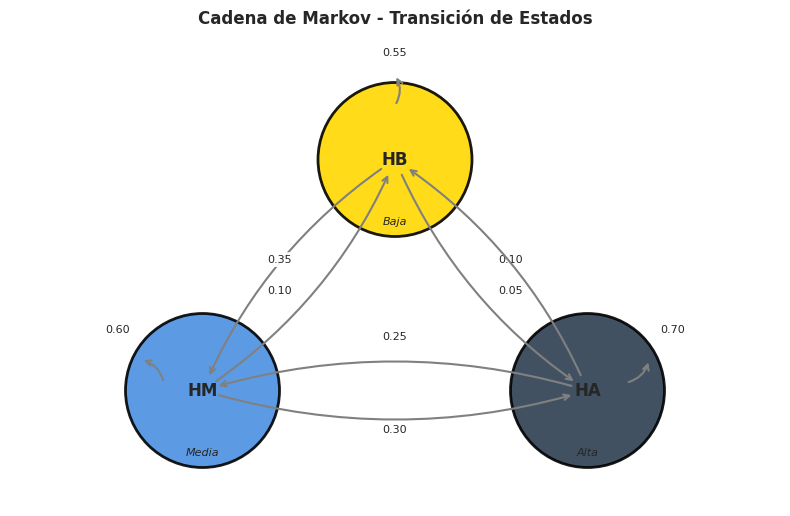


🚀 EJECUTANDO 1000 SIMULACIONES

🔄 Ejecutando 1000 simulaciones de 30 días cada una...
   Simulación 100/1000 completada
   Simulación 200/1000 completada
   Simulación 300/1000 completada
   Simulación 400/1000 completada
   Simulación 500/1000 completada
   Simulación 600/1000 completada
   Simulación 700/1000 completada
   Simulación 800/1000 completada
   Simulación 900/1000 completada
   Simulación 1000/1000 completada

📈 RESULTADOS AGREGADOS

📊 Estadísticas de 1000 simulaciones (30 días c/u):
   🌧️ Días lluviosos promedio:     13.9 ± 2.9 días
   ⛈️ Días tormenta promedio:      10.9 ± 3.5 días
   ☀️ Días soleados promedio:      5.2 ± 3.0 días

   💧 Proporción de lluvia:        82.6% ± 9.9%
   📊 Intervalo de confianza 90%:  [63.3%, 96.7%]

💧 Distribución de humedad (promedio):
   Humedad Baja (HB):  14.2%
   Humedad Media (HM): 40.3%
   Humedad Alta (HA):  45.5%

🎯 Comparación con datos reales:
   Lluvia real:        70.0%
   Lluvia simulada:    82.6%
   Diferencia:         12.6%
 

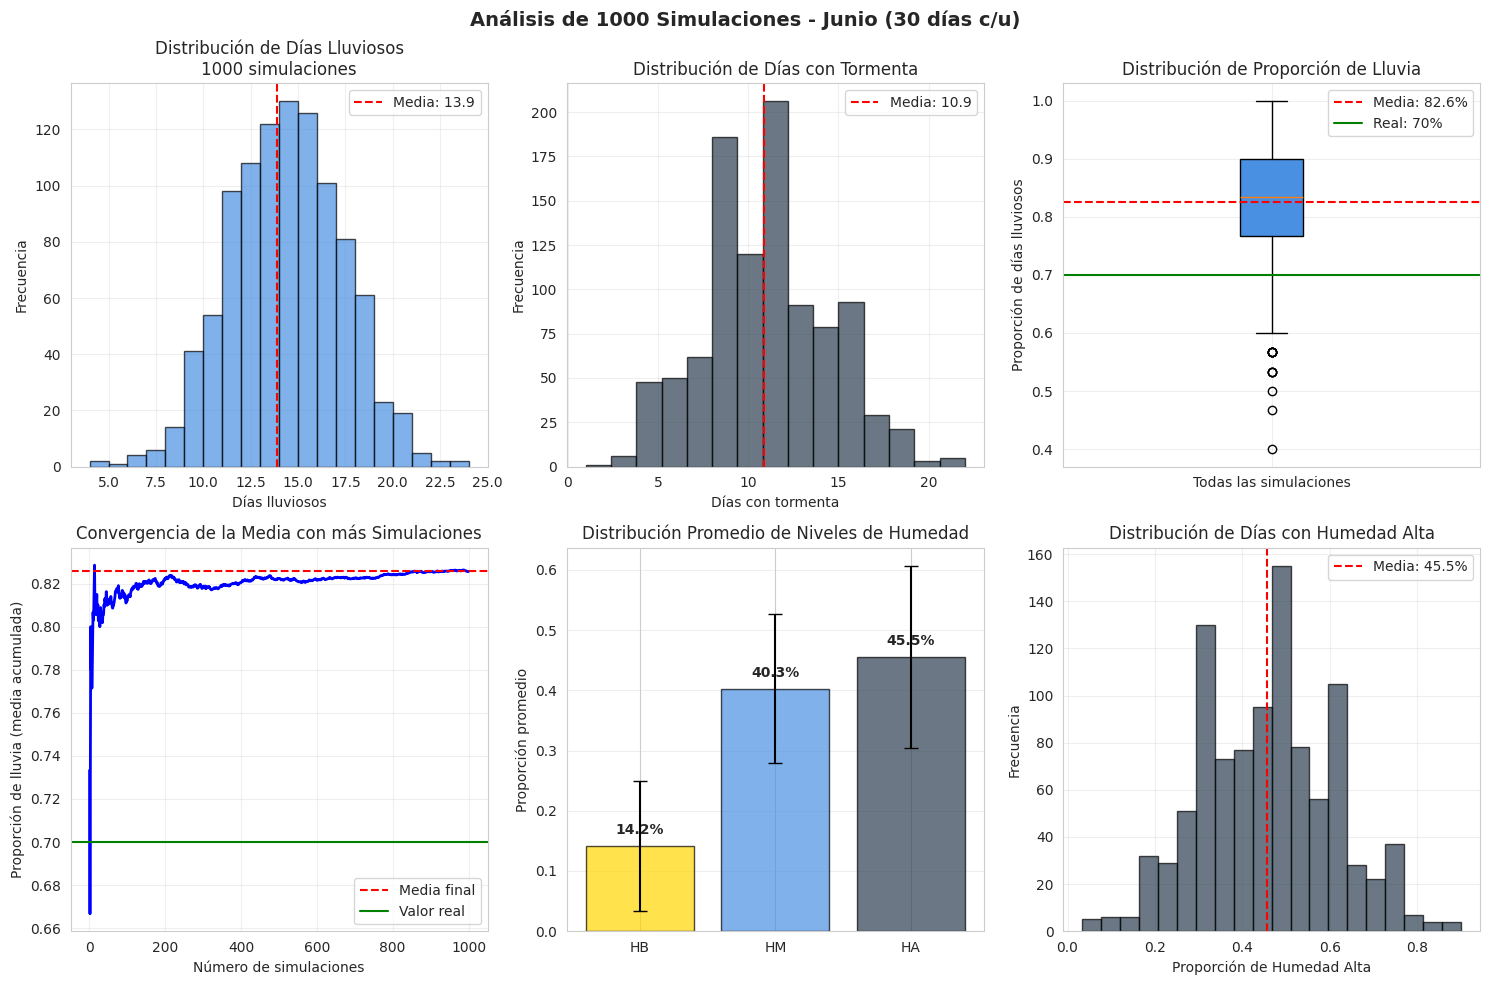


📋 RESUMEN EJECUTIVO

    Mes simulado:           Junio
    Número de simulaciones: 1000
    Días por simulación:    30

    MATRIZ DE TRANSICIÓN (A) - Valores decimales:
    ┌─────────────────────────────────────────────────┐
    │         HB     HM     HA                        │
    │   HB   0.55    0.35    0.10                     │
    │   HM   0.10    0.60    0.30                     │
    │   HA   0.05    0.25    0.70                     │
    └─────────────────────────────────────────────────┘

    RESULTADOS:
    ┌─────────────────────────────────────────────────┐
    │  Días lluviosos:    13.9 ± 2.9 días       │
    │  Días tormenta:     10.9 ± 3.5 días       │
    │  Días soleados:     5.2 ± 3.0 días       │
    │  Proporción lluvia: 82.6% ± 9.9%         │
    └─────────────────────────────────────────────────┘
    

¿Desea realizar más simulaciones? (s/n): n

✨ ¡Gracias por usar el simulador HMM de Medellín! ✨


In [2]:
"""
================================================================================
HMM INTERACTIVO  - CLIMA DE MEDELLÍN
================================================================================
Modelo basado en niveles de HUMEDAD.
- SIN SEMILLA: cada ejecución es diferente (aleatorio)
- Diagrama de estados compacto con valores decimales de la matriz
- Control total del número de simulaciones

Autor: Jorge Jaramillo - Johan Orrego
Fecha: 2026
================================================================================
"""

import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.patches import ConnectionPatch

warnings.filterwarnings('ignore')

# Configuración para gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'


class HiddenMarkovModel:
    """
    Modelo Oculto de Markov (HMM) para simulación climática mensual.
    """

    def __init__(self, estados, observaciones, A, B, pi):
        """
        Inicializa el HMM (NO usa semilla, siempre aleatorio)
        """
        self.estados = estados
        self.observaciones = observaciones
        self.n_estados = len(estados)
        self.n_obs = len(observaciones)

        self.A = np.array(A, dtype=float)
        self.B = np.array(B, dtype=float)
        self.pi = np.array(pi, dtype=float)

        self.estado_a_idx = {estado: i for i, estado in enumerate(estados)}
        self.obs_a_idx = {obs: i for i, obs in enumerate(observaciones)}
        self.idx_a_estado = {i: estado for i, estado in enumerate(estados)}
        self.idx_a_obs = {i: obs for i, obs in enumerate(observaciones)}

    def generar_secuencia(self, n_pasos):
        """Genera una secuencia de estados y observaciones (aleatorio)"""
        estados_idx = np.zeros(n_pasos, dtype=int)
        observaciones_idx = np.zeros(n_pasos, dtype=int)

        estados_idx[0] = np.random.choice(self.n_estados, p=self.pi)
        observaciones_idx[0] = np.random.choice(self.n_obs, p=self.B[estados_idx[0]])

        for t in range(1, n_pasos):
            estados_idx[t] = np.random.choice(self.n_estados, p=self.A[estados_idx[t-1]])
            observaciones_idx[t] = np.random.choice(self.n_obs, p=self.B[estados_idx[t]])

        estados_nombres = [self.idx_a_estado[i] for i in estados_idx]
        observaciones_nombres = [self.idx_a_obs[i] for i in observaciones_idx]

        return estados_nombres, observaciones_nombres

    def simular_multiples(self, n_simulaciones, dias_por_simulacion, verbose=True):
        """
        Realiza múltiples simulaciones y retorna estadísticas agregadas.
        """
        resultados = []

        if verbose:
            print(f"\n🔄 Ejecutando {n_simulaciones} simulaciones de {dias_por_simulacion} días cada una...")

        for i in range(n_simulaciones):
            if verbose and (i+1) % max(1, n_simulaciones//10) == 0:
                print(f"   Simulación {i+1}/{n_simulaciones} completada")

            estados, observaciones = self.generar_secuencia(dias_por_simulacion)

            freq_obs = Counter(observaciones)
            freq_est = Counter(estados)

            resultados.append({
                'simulacion': i+1,
                'dias_soleados': freq_obs.get('Soleado', 0),
                'dias_lluvia': freq_obs.get('Lluvia', 0),
                'dias_tormenta': freq_obs.get('Tormenta', 0),
                'dias_HB': freq_est.get('Humedad Baja', 0),
                'dias_HM': freq_est.get('Humedad Media', 0),
                'dias_HA': freq_est.get('Humedad Alta', 0),
                'prop_lluvia': (freq_obs.get('Lluvia', 0) + freq_obs.get('Tormenta', 0)) / dias_por_simulacion,
                'prop_HB': freq_est.get('Humedad Baja', 0) / dias_por_simulacion,
                'prop_HM': freq_est.get('Humedad Media', 0) / dias_por_simulacion,
                'prop_HA': freq_est.get('Humedad Alta', 0) / dias_por_simulacion
            })

        df_resultados = pd.DataFrame(resultados)

        stats = {
            'n_simulaciones': n_simulaciones,
            'dias_por_simulacion': dias_por_simulacion,
            'media_dias_soleados': df_resultados['dias_soleados'].mean(),
            'std_dias_soleados': df_resultados['dias_soleados'].std(),
            'media_dias_lluvia': df_resultados['dias_lluvia'].mean(),
            'std_dias_lluvia': df_resultados['dias_lluvia'].std(),
            'media_dias_tormenta': df_resultados['dias_tormenta'].mean(),
            'std_dias_tormenta': df_resultados['dias_tormenta'].std(),
            'media_prop_lluvia': df_resultados['prop_lluvia'].mean(),
            'std_prop_lluvia': df_resultados['prop_lluvia'].std(),
            'media_prop_HB': df_resultados['prop_HB'].mean(),
            'media_prop_HM': df_resultados['prop_HM'].mean(),
            'media_prop_HA': df_resultados['prop_HA'].mean(),
            'percentil_5_lluvia': df_resultados['prop_lluvia'].quantile(0.05),
            'percentil_95_lluvia': df_resultados['prop_lluvia'].quantile(0.95),
            'df_resultados': df_resultados
        }

        return stats

    def graficar_diagrama_estados_pequeno(self):
        """
        Diagrama de transición de estados MÁS PEQUEÑO con valores decimales de la matriz
        """
        fig, ax = plt.subplots(figsize=(8, 6))

        # Posiciones de los nodos (más compactas)
        pos = {
            0: (0.5, 0.65),   # HB (arriba)
            1: (0.25, 0.35),  # HM (izquierda)
            2: (0.75, 0.35)   # HA (derecha)
        }

        # Colores
        colores = {0: '#ffd700', 1: '#4a90e2', 2: '#2c3e50'}

        # Nombres cortos
        nombres = {0: 'HB', 1: 'HM', 2: 'HA'}
        descripciones = {0: 'Baja', 1: 'Media', 2: 'Alta'}

        # Dibujar nodos (más pequeños)
        for estado in range(self.n_estados):
            circle = Circle(pos[estado], 0.10, facecolor=colores[estado],
                           edgecolor='black', linewidth=2, alpha=0.9)
            ax.add_patch(circle)
            ax.text(pos[estado][0], pos[estado][1], nombres[estado],
                   ha='center', va='center', fontsize=12, fontweight='bold')
            ax.text(pos[estado][0], pos[estado][1] - 0.08, descripciones[estado],
                   ha='center', va='center', fontsize=8, style='italic')

        # Dibujar flechas de transición con valores decimales
        for i in range(self.n_estados):
            for j in range(self.n_estados):
                prob = self.A[i, j]
                if prob > 0:
                    # Calcular dirección
                    dx = pos[j][0] - pos[i][0]
                    dy = pos[j][1] - pos[i][1]

                    # Auto-transición (flecha curva)
                    if i == j:
                        if i == 0:  # HB
                            ax.annotate('', xy=(0.5, 0.76), xytext=(0.5, 0.72),
                                       arrowprops=dict(arrowstyle='->', color='gray', lw=1.5,
                                                      connectionstyle='arc3,rad=0.3'))
                            ax.text(0.5, 0.79, f'{prob:.2f}', ha='center', va='center',
                                   fontsize=8, bbox=dict(boxstyle='round,pad=0.2',
                                                        facecolor='white', alpha=0.9))
                        elif i == 1:  # HM
                            ax.annotate('', xy=(0.17, 0.39), xytext=(0.20, 0.36),
                                       arrowprops=dict(arrowstyle='->', color='gray', lw=1.5,
                                                      connectionstyle='arc3,rad=0.3'))
                            ax.text(0.14, 0.43, f'{prob:.2f}', ha='center', va='center',
                                   fontsize=8, bbox=dict(boxstyle='round,pad=0.2',
                                                        facecolor='white', alpha=0.9))
                        else:  # HA
                            ax.annotate('', xy=(0.83, 0.39), xytext=(0.80, 0.36),
                                       arrowprops=dict(arrowstyle='->', color='gray', lw=1.5,
                                                      connectionstyle='arc3,rad=0.3'))
                            ax.text(0.86, 0.43, f'{prob:.2f}', ha='center', va='center',
                                   fontsize=8, bbox=dict(boxstyle='round,pad=0.2',
                                                        facecolor='white', alpha=0.9))
                    else:
                        # Flecha entre diferentes estados
                        ax.annotate('', xy=pos[j], xytext=pos[i],
                                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5,
                                                  connectionstyle='arc3,rad=0.15',
                                                  shrinkA=12, shrinkB=12))

                        # Posición media para la etiqueta
                        mid_x = (pos[i][0] + pos[j][0]) / 2
                        mid_y = (pos[i][1] + pos[j][1]) / 2

                        # Ajuste para evitar solapamiento
                        if i == 0 and j == 1:
                            mid_x, mid_y = 0.35, 0.52
                        elif i == 0 and j == 2:
                            mid_x, mid_y = 0.65, 0.52
                        elif i == 1 and j == 2:
                            mid_x, mid_y = 0.50, 0.30
                        elif i == 1 and j == 0:
                            mid_x, mid_y = 0.35, 0.48
                        elif i == 2 and j == 0:
                            mid_x, mid_y = 0.65, 0.48
                        elif i == 2 and j == 1:
                            mid_x, mid_y = 0.50, 0.42

                        ax.text(mid_x, mid_y, f'{prob:.2f}', ha='center', va='center',
                               fontsize=8, bbox=dict(boxstyle='round,pad=0.15',
                                                    facecolor='white', alpha=0.9))

        ax.set_xlim(0, 1)
        ax.set_ylim(0.2, 0.8)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title('Cadena de Markov - Transición de Estados',
                    fontsize=12, fontweight='bold', pad=15)

        plt.tight_layout()
        plt.show()

    def graficar_distribucion_simulaciones(self, stats, mes, datos_reales=None):
        """
        Grafica la distribución de resultados de las múltiples simulaciones
        """
        df = stats['df_resultados']

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # 1. Distribución de días lluviosos
        ax1 = axes[0, 0]
        ax1.hist(df['dias_lluvia'], bins=20, alpha=0.7, color='#4a90e2', edgecolor='black')
        ax1.axvline(stats['media_dias_lluvia'], color='red', linestyle='--',
                   label=f'Media: {stats["media_dias_lluvia"]:.1f}')
        ax1.set_xlabel('Días lluviosos')
        ax1.set_ylabel('Frecuencia')
        ax1.set_title(f'Distribución de Días Lluviosos\n{stats["n_simulaciones"]} simulaciones')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Distribución de días con tormenta
        ax2 = axes[0, 1]
        ax2.hist(df['dias_tormenta'], bins=15, alpha=0.7, color='#2c3e50', edgecolor='black')
        ax2.axvline(stats['media_dias_tormenta'], color='red', linestyle='--',
                   label=f'Media: {stats["media_dias_tormenta"]:.1f}')
        ax2.set_xlabel('Días con tormenta')
        ax2.set_ylabel('Frecuencia')
        ax2.set_title('Distribución de Días con Tormenta')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Boxplot de proporción de lluvia
        ax3 = axes[0, 2]
        bp = ax3.boxplot(df['prop_lluvia'], patch_artist=True)
        bp['boxes'][0].set_facecolor('#4a90e2')
        ax3.axhline(stats['media_prop_lluvia'], color='red', linestyle='--',
                   label=f'Media: {stats["media_prop_lluvia"]:.1%}')
        if datos_reales:
            ax3.axhline(datos_reales['dias_lluvia']/datos_reales['dias'], color='green',
                       linestyle='-', label=f'Real: {datos_reales["dias_lluvia"]/datos_reales["dias"]:.0%}')
        ax3.set_ylabel('Proporción de días lluviosos')
        ax3.set_title('Distribución de Proporción de Lluvia')
        ax3.set_xticklabels(['Todas las simulaciones'])
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. Evolución de la media con más simulaciones
        ax4 = axes[1, 0]
        medias_acumuladas = df['prop_lluvia'].expanding().mean()
        ax4.plot(range(1, len(medias_acumuladas)+1), medias_acumuladas, 'b-', linewidth=2)
        ax4.axhline(stats['media_prop_lluvia'], color='red', linestyle='--', label='Media final')
        if datos_reales:
            ax4.axhline(datos_reales['dias_lluvia']/datos_reales['dias'], color='green',
                       linestyle='-', label='Valor real')
        ax4.set_xlabel('Número de simulaciones')
        ax4.set_ylabel('Proporción de lluvia (media acumulada)')
        ax4.set_title('Convergencia de la Media con más Simulaciones')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # 5. Distribución de niveles de humedad
        ax5 = axes[1, 1]
        humedades = ['HB', 'HM', 'HA']
        medias_humedad = [stats['media_prop_HB'], stats['media_prop_HM'], stats['media_prop_HA']]
        stds_humedad = [df['prop_HB'].std(), df['prop_HM'].std(), df['prop_HA'].std()]

        bars = ax5.bar(humedades, medias_humedad, yerr=stds_humedad,
                      color=['#ffd700', '#4a90e2', '#2c3e50'],
                      alpha=0.7, edgecolor='black', capsize=5)
        ax5.set_ylabel('Proporción promedio')
        ax5.set_title('Distribución Promedio de Niveles de Humedad')
        for bar, val in zip(bars, medias_humedad):
            ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.1%}', ha='center', fontweight='bold')
        ax5.grid(True, alpha=0.3, axis='y')

        # 6. Histograma de distribución de humedad alta
        ax6 = axes[1, 2]
        ax6.hist(df['prop_HA'], bins=20, alpha=0.7, color='#2c3e50', edgecolor='black')
        ax6.axvline(stats['media_prop_HA'], color='red', linestyle='--',
                   label=f'Media: {stats["media_prop_HA"]:.1%}')
        ax6.set_xlabel('Proporción de Humedad Alta')
        ax6.set_ylabel('Frecuencia')
        ax6.set_title('Distribución de Días con Humedad Alta')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        plt.suptitle(f'Análisis de {stats["n_simulaciones"]} Simulaciones - {mes} ({stats["dias_por_simulacion"]} días c/u)',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()


# ==============================================================================
# DATOS CLIMÁTICOS REALES DE MEDELLÍN
# ==============================================================================

def obtener_datos_mes(mes):
    """Retorna los parámetros climáticos reales de Medellín"""

    datos_mensuales = {
        'Junio': {'dias': 30, 'dias_lluvia': 21, 'humedad_promedio': 82,
                  'temp_min': 12, 'temp_max': 24, 'precipitacion': 431,
                  'descripcion': 'Mes muy lluvioso, humedad alta constante'},
        'Julio': {'dias': 31, 'dias_lluvia': 19, 'humedad_promedio': 78,
                  'temp_min': 12, 'temp_max': 25, 'precipitacion': 348,
                  'descripcion': 'Humedad alta pero con días más secos'},
        'Agosto': {'dias': 31, 'dias_lluvia': 20, 'humedad_promedio': 79,
                   'temp_min': 12, 'temp_max': 25, 'precipitacion': 392,
                   'descripcion': 'Segundo pico de lluvias, humedad persistente'},
        'Septiembre': {'dias': 30, 'dias_lluvia': 21, 'humedad_promedio': 83,
                       'temp_min': 12, 'temp_max': 24, 'precipitacion': 428,
                       'descripcion': 'Humedad máxima del año'},
        'Octubre': {'dias': 31, 'dias_lluvia': 23, 'humedad_promedio': 85,
                    'temp_min': 12, 'temp_max': 24, 'precipitacion': 470,
                    'descripcion': 'Mes más húmedo, tormentas frecuentes'},
        'Noviembre': {'dias': 30, 'dias_lluvia': 20, 'humedad_promedio': 80,
                      'temp_min': 12, 'temp_max': 24, 'precipitacion': 389,
                      'descripcion': 'Disminución gradual de humedad'},
        'Diciembre': {'dias': 31, 'dias_lluvia': 14, 'humedad_promedio': 72,
                      'temp_min': 12, 'temp_max': 24, 'precipitacion': 210,
                      'descripcion': 'Humedad más baja, inicio de temporada seca'}
    }

    return datos_mensuales.get(mes)


def ajustar_matrices_por_mes(mes):
    """Ajusta las matrices según el mes seleccionado"""

    datos = obtener_datos_mes(mes)
    humedad = datos['humedad_promedio']

    if humedad >= 80:  # Meses muy húmedos (Junio, Septiembre, Octubre)
        A = [[0.55, 0.35, 0.10], [0.10, 0.60, 0.30], [0.05, 0.25, 0.70]]
        B = [[0.80, 0.18, 0.02], [0.15, 0.75, 0.10], [0.00, 0.30, 0.70]]
        pi = [0.20, 0.40, 0.40]
    elif humedad >= 75:  # Meses húmedos (Julio, Agosto, Noviembre)
        A = [[0.60, 0.30, 0.10], [0.15, 0.65, 0.20], [0.08, 0.35, 0.57]]
        B = [[0.85, 0.13, 0.02], [0.20, 0.70, 0.10], [0.00, 0.40, 0.60]]
        pi = [0.30, 0.45, 0.25]
    else:  # Meses más secos (Diciembre)
        A = [[0.75, 0.20, 0.05], [0.25, 0.60, 0.15], [0.15, 0.40, 0.45]]
        B = [[0.90, 0.10, 0.00], [0.25, 0.68, 0.07], [0.00, 0.45, 0.55]]
        pi = [0.50, 0.35, 0.15]

    return A, B, pi


# ==============================================================================
# FUNCIÓN PRINCIPAL - SIN SEMILLA
# ==============================================================================

def simular_clima_sin_semilla():
    """Función principal SIN semilla (aleatorio siempre)"""

    print("="*70)
    print("🌧️ SIMULADOR HMM - CLIMA DE MEDELLÍN (SIN SEMILLA)")
    print("="*70)

    # Mostrar meses
    print("\n📅 MESES DISPONIBLES:")
    print("-" * 65)
    meses = ['Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

    for i, mes in enumerate(meses, 1):
        datos = obtener_datos_mes(mes)
        print(f"{i}. {mes:10s} - {datos['dias']} días | {datos['dias_lluvia']} días lluvia | "
              f"Humedad: {datos['humedad_promedio']}%")
    print("-" * 65)

    # Selección del mes
    while True:
        try:
            opcion = input("\n📌 Seleccione el mes (1-7): ")
            idx = int(opcion) - 1
            if 0 <= idx < len(meses):
                mes_seleccionado = meses[idx]
                break
            else:
                print("Opción inválida. Ingrese un número entre 1 y 7.")
        except:
            print("Por favor, ingrese un número válido.")

    datos_mes = obtener_datos_mes(mes_seleccionado)

    # Mostrar información del mes
    print("\n" + "="*70)
    print(f"📊 INFORMACIÓN CLIMÁTICA - {mes_seleccionado.upper()}")
    print("="*70)
    print(f"📅 Días del mes:         {datos_mes['dias']}")
    print(f"☔ Días con lluvia:      {datos_mes['dias_lluvia']} ({datos_mes['dias_lluvia']/datos_mes['dias']:.0%})")
    print(f"💧 Humedad promedio:     {datos_mes['humedad_promedio']}%")
    print(f"🌡️ Temperatura:          {datos_mes['temp_min']}°C - {datos_mes['temp_max']}°C")

    # ===== CONFIGURACIÓN DE PARÁMETROS =====
    print("\n" + "="*70)
    print("⚙️ CONFIGURACIÓN DE PARÁMETROS")
    print("="*70)

    # NÚMERO DE SIMULACIONES
    while True:
        try:
            n_simulaciones = input("\n📊 ¿Cuántas simulaciones desea ejecutar? (1-1000, Enter=30): ")
            if n_simulaciones.strip():
                n_simulaciones = int(n_simulaciones)
                if 1 <= n_simulaciones <= 1000:
                    break
                else:
                    print("  Ingrese un número entre 1 y 1000")
            else:
                n_simulaciones = 30
                break
        except:
            n_simulaciones = 30
            break

    # Días por simulación
    while True:
        try:
            dias_por_sim = input(f"\n📆 ¿Cuántos días por simulación? (1-{datos_mes['dias']}, Enter={datos_mes['dias']}): ")
            if dias_por_sim.strip():
                dias_por_sim = int(dias_por_sim)
                if 1 <= dias_por_sim <= datos_mes['dias']:
                    break
                else:
                    print(f"  Ingrese un número entre 1 y {datos_mes['dias']}")
            else:
                dias_por_sim = datos_mes['dias']
                break
        except:
            dias_por_sim = datos_mes['dias']
            break

    # Ajustar matrices
    A, B, pi = ajustar_matrices_por_mes(mes_seleccionado)
    estados = ['Humedad Baja', 'Humedad Media', 'Humedad Alta']
    observaciones = ['Soleado', 'Lluvia', 'Tormenta']

    # Crear modelo (SIN SEMILLA)
    hmm = HiddenMarkovModel(estados, observaciones, A, B, pi)

    # Mostrar matrices
    print("\n" + "="*70)
    print("📐 MATRICES DEL MODELO")
    print("="*70)
    print("\nMatriz de Transición (A) - Valores decimales:")
    df_A = pd.DataFrame(A, index=estados, columns=estados)
    print(df_A.round(3))

    print("\nMatriz de Emisión (B) - Valores decimales:")
    df_B = pd.DataFrame(B, index=estados, columns=observaciones)
    print(df_B.round(3))

    # Diagrama de estados pequeño con valores decimales
    print("\n📊 Diagrama de transición de estados (con valores decimales):")
    hmm.graficar_diagrama_estados_pequeno()

    # ===== EJECUTAR MÚLTIPLES SIMULACIONES =====
    print(f"\n" + "="*70)
    print(f"🚀 EJECUTANDO {n_simulaciones} SIMULACIONES")
    print("="*70)

    stats = hmm.simular_multiples(n_simulaciones, dias_por_sim, verbose=True)

    # Mostrar resultados agregados
    print("\n" + "="*70)
    print("📈 RESULTADOS AGREGADOS")
    print("="*70)

    print(f"\n📊 Estadísticas de {n_simulaciones} simulaciones ({dias_por_sim} días c/u):")
    print(f"   🌧️ Días lluviosos promedio:     {stats['media_dias_lluvia']:.1f} ± {stats['std_dias_lluvia']:.1f} días")
    print(f"   ⛈️ Días tormenta promedio:      {stats['media_dias_tormenta']:.1f} ± {stats['std_dias_tormenta']:.1f} días")
    print(f"   ☀️ Días soleados promedio:      {stats['media_dias_soleados']:.1f} ± {stats['std_dias_soleados']:.1f} días")
    print(f"\n   💧 Proporción de lluvia:        {stats['media_prop_lluvia']:.1%} ± {stats['std_prop_lluvia']:.1%}")
    print(f"   📊 Intervalo de confianza 90%:  [{stats['percentil_5_lluvia']:.1%}, {stats['percentil_95_lluvia']:.1%}]")

    print(f"\n💧 Distribución de humedad (promedio):")
    print(f"   Humedad Baja (HB):  {stats['media_prop_HB']:.1%}")
    print(f"   Humedad Media (HM): {stats['media_prop_HM']:.1%}")
    print(f"   Humedad Alta (HA):  {stats['media_prop_HA']:.1%}")

    # Comparación con datos reales
    prop_real = datos_mes['dias_lluvia'] / datos_mes['dias']
    print(f"\n🎯 Comparación con datos reales:")
    print(f"   Lluvia real:        {prop_real:.1%}")
    print(f"   Lluvia simulada:    {stats['media_prop_lluvia']:.1%}")
    print(f"   Diferencia:         {abs(prop_real - stats['media_prop_lluvia']):.1%}")

    if abs(prop_real - stats['media_prop_lluvia']) < 0.05:
        print("   ✅ Excelente! El modelo es muy preciso.")
    elif abs(prop_real - stats['media_prop_lluvia']) < 0.10:
        print("   ✓ Buena aproximación.")
    else:
        print("   ⚠️ La simulación difiere. Pruebe con más simulaciones.")

    # Gráficos de distribución
    print("\n📊 Generando gráficos de distribución de simulaciones...")
    hmm.graficar_distribucion_simulaciones(stats, mes_seleccionado, datos_mes)


    # Resumen ejecutivo
    print("\n" + "="*70)
    print("📋 RESUMEN EJECUTIVO")
    print("="*70)
    print(f"""
    Mes simulado:           {mes_seleccionado}
    Número de simulaciones: {n_simulaciones}
    Días por simulación:    {dias_por_sim}

    MATRIZ DE TRANSICIÓN (A) - Valores decimales:
    ┌─────────────────────────────────────────────────┐
    │         HB     HM     HA                        │
    │   HB   {A[0][0]:.2f}    {A[0][1]:.2f}    {A[0][2]:.2f}                     │
    │   HM   {A[1][0]:.2f}    {A[1][1]:.2f}    {A[1][2]:.2f}                     │
    │   HA   {A[2][0]:.2f}    {A[2][1]:.2f}    {A[2][2]:.2f}                     │
    └─────────────────────────────────────────────────┘

    RESULTADOS:
    ┌─────────────────────────────────────────────────┐
    │  Días lluviosos:    {stats['media_dias_lluvia']:.1f} ± {stats['std_dias_lluvia']:.1f} días       │
    │  Días tormenta:     {stats['media_dias_tormenta']:.1f} ± {stats['std_dias_tormenta']:.1f} días       │
    │  Días soleados:     {stats['media_dias_soleados']:.1f} ± {stats['std_dias_soleados']:.1f} días       │
    │  Proporción lluvia: {stats['media_prop_lluvia']:.1%} ± {stats['std_prop_lluvia']:.1%}         │
    └─────────────────────────────────────────────────┘
    """)

    return hmm, stats


# ==============================================================================
# EJECUTAR
# ==============================================================================

if __name__ == "__main__":
    print("""
    ╔══════════════════════════════════════════════════════════════════════╗
    ║                                                                      ║
    ║     🌧️ SIMULADOR HMM - CLIMA DE MEDELLÍN 🌧️                          ║
    ║                                                                      ║
    ║  CARACTERÍSTICAS:                                                    ║    ║  • SIN SEMILLA: Cada ejecución es diferente (aleatorio real)         ║
    ║  • Diagrama de estados COMPACTO con valores decimales de la matriz   ║
    ║  • Control TOTAL del número de simulaciones                          ║
    ║  • Estadísticas con intervalos de confianza                          ║
    ║                                                                      ║
    ║  MODELO BASADO EN NIVELES DE HUMEDAD:                                ║
    ║  • HB (Humedad Baja)  → Días secos y soleados ☀️                     ║
    ║  • HM (Humedad Media) → Días nublados, lluvias ligeras 🌧️           ║
    ║  • HA (Humedad Alta)  → Tormentas y lluvias fuertes ⛈️              ║
    ║                                                                      ║
    ╚══════════════════════════════════════════════════════════════════════╝
    """)

    while True:
        simular_clima_sin_semilla()

        repetir = input("\n¿Desea realizar más simulaciones? (s/n): ").lower()
        if repetir != 's':
            print("\n✨ ¡Gracias por usar el simulador HMM de Medellín! ✨")
            break
        print("\n" + "🔄" * 35 + "\n")